### Dataset Link: [Healthcare_Dataset](https://drive.google.com/file/d/1Tlv9_bF9Ll5eyAniizQUJgeLfQwe_Ory/view)

In [4]:
# Import libraries and loading dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

df.info()

df.head()

Saving healthcare_data_cleaning_dataset.csv to healthcare_data_cleaning_dataset (3).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Patient_ID          5100 non-null   int64  
 1   Age                 4500 non-null   float64
 2   Gender              5100 non-null   object 
 3   City                5100 non-null   object 
 4   Diagnosis           5100 non-null   object 
 5   Hospital_Visits     5100 non-null   int64  
 6   Treatment_Cost      4507 non-null   float64
 7   Insurance_Coverage  5100 non-null   int64  
 8   Admission_Date      5100 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 358.7+ KB


,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20


### Q1. Missing Data Identification
**Scenario:**
The hospital suspects incomplete patient records

**Task:**
- Identify missing values in each column.
- Calculate percentage of missing data

In [5]:
# Solution Q1
missing_data = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_data

,Missing Values,Missing_Percentage
Patient_ID,0,0.00
Age,600,11.76
Gender,0,0.00
City,0,0.00
Diagnosis,0,0.00
Hospital_Visits,0,0.00
Treatment_Cost,593,11.63
Insurance_Coverage,0,0.00
Admission_Date,0,0.00


### Conclusion:
Missing data exists only in Age and Treatment_Cost.

### Q2. Handling Missing Age
**Scenario:**
Age is critical for medical analysis, but some values are missing.

**Task:**
- Replace missing age values with an appropriate method
- Justify your choice (mean/median)

In [8]:
# Solution Q2
print("Mean Age:", df['Age'].mean())
print("\nMedian Age:", df['Age'].median())

# Replace missing age values with median
df['Age'] = df['Age'].fillna(df['Age'].median())

print("\nMissing Age values after imputation:",df['Age'].isnull().sum())

Mean Age: 49.64490196078432

Median Age: 50.0

Missing Age values after imputation: 0


### Justification
Median is preferred because age is a numerical variable and median is more robust to extreme values/outliers than the mean. It also gives a realistic whole-number central age in this dataset.

### Q3. Handling Missing Treatment Cost
**Scenario:**
Treatment cost is highly skewed due to expensive treatments.

**Task:**
- Handle missing Treatment_Cost values
- Choose the correct imputation method and explain why.

In [9]:
# Solution Q3
print("Mean Treatment Cost:", df['Treatment_Cost'].mean())
print("\nMedian Treatment Cost:", df['Treatment_Cost'].median())

# Replace missing treatment cost values with median
df['Treatment_Cost'] = df['Treatment_Cost'].fillna(df['Treatment_Cost'].median())

print("\nMissing Treatment Cost values after imputation:",df['Treatment_Cost'].isnull().sum())

Mean Treatment Cost: 26920.151157458764

Median Treatment Cost: 24797.0

Missing Treatment Cost values after imputation: 0


### Justification
Median is an appropriate method because Treatment Cost is highly skewed. Expensive treatments can significantly increase the mean, whereas the median is much less affected by extreme values.

### Q4. Duplicate Patient Records
**Scenario:**
Some patient records were entered multiple times.

**Task:**
- Identify duplicate rows
- Remove duplicates
- Compare dataset size before and after

In [10]:
# Solution Q4

# Find duplicate rows
duplicate_rows = df[df.duplicated(keep=False)]

print("Number of duplicate rows:", len(duplicate_rows))
duplicate_rows.head()

# Duplicate rows that can be removed
removable_rows = df.duplicated().sum()
print("\nDuplicate rows to remove:", removable_rows)

# Remove duplicates
df_cleaned = df.drop_duplicates()

print("\nSize of dataset before removing duplicates:", len(df))
print("\nSize of dataset after removing duplicates:", len(df_cleaned))

print("\nDuplicates removed:", len(df) - len(df_cleaned))

print("\nRemaining duplicate rows:", df_cleaned.duplicated().sum())

Number of duplicate rows: 198

Duplicate rows to remove: 99

Size of dataset before removing duplicates: 5100

Size of dataset after removing duplicates: 5001

Duplicates removed: 99

Remaining duplicate rows: 0


### Q5. Invalid Age Values (Data Quality Check)
**Scenario:**
Some patients have unrealistic age values (eg, > 100 or < 0)

**Task:**
- Detect such records
- Decide whether to remove or correct them

In [13]:
# Solution Q5
invalid_age_rows = df[(df['Age'] > 100) | (df['Age'] < 0)]

print("Number of invalid age rows:", len(invalid_age_rows))
invalid_age_rows.head()

print("\nMinimum Age in dataset:", df['Age'].min())
print("\nMaximum Age in dataset:", df['Age'].max())

Number of invalid age rows: 0

Minimum Age in dataset: 0.0

Maximum Age in dataset: 99.0


### Decision
Since the dataset has minimum age = 0 and maximum age = 99.
Therefore, there are no values below 0 or above 100.
So, No records need to be removed or corrected. If invalid values had existed, we could have handled them using:
```
df_cleaned.loc[
  (df_cleaned['Age'] < 0) |
  (df_cleaned['Age'] > 100),
  'Age'
] = np.nan
```
Then the resulting missing values could be imputed using the median.

### Q6. Outlier Detection (Treatment Cost)
**Scenario:**
Extreme treatment cost are affecting analysis.

**Task:**
- Detect outliers using IQR method
- Display number of outliers

In [17]:
# Solution Q6

# Calculation of Q1 and Q3
Q1 = df_cleaned['Treatment_Cost'].quantile(0.25)
Q3 = df_cleaned['Treatment_Cost'].quantile(0.75)

print(f"Q1 is {Q1} and \nQ3 is {Q3}")
# Calculation of IQR
IQR = Q3 - Q1
print(f"\nIQR is {IQR}")

# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"\nLower bound is {lower_bound} and \nupper bound is {upper_bound}")

# Identify outliers
outliers = df_cleaned[(df_cleaned['Treatment_Cost'] < lower_bound) | (df_cleaned['Treatment_Cost'] > upper_bound)]
print("\nNumber of Treatment Cost outliers:", len(outliers))

# Display of outliers
outliers[['Patient_ID', 'Treatment_Cost']].head(20)

Q1 is 13766.0 and 
Q3 is 36542.0

IQR is 22776.0

Lower bound is -20398.0 and 
upper bound is 70706.0

Number of Treatment Cost outliers: 50


,Patient_ID,Treatment_Cost
53,13152,199702.965333
86,10064,199702.965333
124,17035,199702.965333
183,15855,199702.965333
215,19561,199702.965333
332,11686,199702.965333
382,10876,199702.965333
416,14070,199702.965333
452,10851,199702.965333
796,18150,199702.965333


### Conclusion
There are 50 Treatment Cost outliers according to the IQR method.

### Q7. Outlier Treatment
**Scenario:**
The business team wants to retain all records

**Task:**
- Apply capping (Winsorization) on Treatment_Cost
- Use 5th and 95th percentile

In [20]:
# Solution Q7
lower_percentile = df_cleaned['Treatment_Cost'].quantile(0.05)
upper_percentile = df_cleaned['Treatment_Cost'].quantile(0.95)

print(f"5th percentile is {lower_percentile} \n95th percentile is {upper_percentile}")

df_cleaned['Treatment_Cost_Capped'] = df_cleaned['Treatment_Cost'].clip(
    lower=lower_percentile,
    upper=upper_percentile
)

print(df_cleaned[['Patient_ID', 'Treatment_Cost', 'Treatment_Cost_Capped']].head(10))

print(f"Minimum after capping: {df_cleaned['Treatment_Cost_Capped'].min()} \nMaximum after capping: {df_cleaned['Treatment_Cost_Capped'].max()}")

5th percentile is 3238.0 
95th percentile is 47948.0
   Patient_ID  Treatment_Cost  Treatment_Cost_Capped
0       17270         41010.0                41010.0
1       10860         12194.0                12194.0
2       15390         45086.0                45086.0
3       15191         40842.0                40842.0
4       15734          9873.0                 9873.0
5       16265         11948.0                11948.0
6       10466         31710.0                31710.0
7       14426         25910.0                25910.0
8       15578         24797.0                24797.0
9       18322          3264.0                 3264.0
Minimum after capping: 3238.0 
Maximum after capping: 47948.0


/tmp/ipykernel_838/1198681714.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Treatment_Cost_Capped'] = df_cleaned['Treatment_Cost'].clip(


### Q8. Transformation
**Scenario:**
Treatment cost is highly skewed

**Task:**
- Apply log transformation
- Create a new column
- Compare before vs after distribution

Original Treatment Cost:
count      5001.000000
mean      26710.425768
std       22056.888458
min         526.000000
25%       13766.000000
50%       24797.000000
75%       36542.000000
max      199702.965333
Name: Treatment_Cost, dtype: float64

Log Transformed Treatment Cost:
count    5001.000000
mean        9.901810
std         0.870822
min         6.267201
25%         9.530030
50%        10.118518
75%        10.506245
max        12.204591
Name: Treatment_Cost_Log, dtype: float64


/tmp/ipykernel_838/2246928396.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Treatment_Cost_Log'] = np.log1p(df_cleaned['Treatment_Cost'])


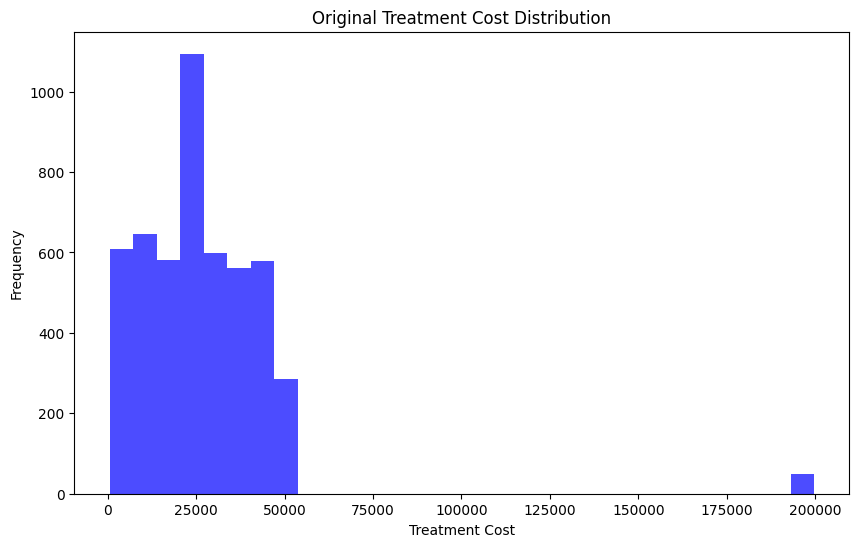

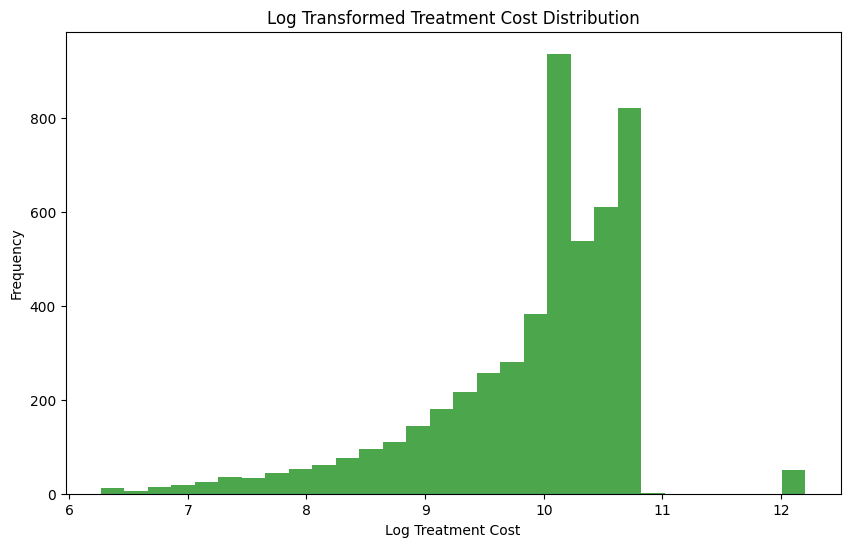


Skewness of Original Treatment Cost: 4.747589524593274

Skewness of Log Transformed Treatment Cost: -1.2325993954304038


In [22]:
# Solution Q8
df_cleaned['Treatment_Cost_Log'] = np.log1p(df_cleaned['Treatment_Cost'])

# log1p(x) calculates log(1 + x) and is convenient for numerical data.

# Compare Statistics
print("Original Treatment Cost:")
print(df_cleaned['Treatment_Cost'].describe())

print("\nLog Transformed Treatment Cost:")
print(df_cleaned['Treatment_Cost_Log'].describe())

# Visual Comparision
# Original Distribution
plt.figure(figsize=(10, 6))
plt.hist(df_cleaned['Treatment_Cost'], bins=30, color='blue', alpha=0.7)
plt.title('Original Treatment Cost Distribution')
plt.xlabel('Treatment Cost')
plt.ylabel('Frequency')
plt.show()

# Log-transformed Distribution
plt.figure(figsize=(10, 6))
plt.hist(df_cleaned['Treatment_Cost_Log'], bins=30, color='green', alpha=0.7)
plt.title('Log Transformed Treatment Cost Distribution')
plt.xlabel('Log Treatment Cost')
plt.ylabel('Frequency')
plt.show()

# Compare Skewness
print("\nSkewness of Original Treatment Cost:", df_cleaned['Treatment_Cost'].skew())
print("\nSkewness of Log Transformed Treatment Cost:", df_cleaned['Treatment_Cost_Log'].skew())

### Conclusion
The log transformation substantially changes the scale and reduces the strong right-skew caused by very expensive treatments. The transformed data is therefore generally more suitable for statistical analysis and visualization.

### Q9. Time-Based Missing Handling
**Scenario:**
Admission dates should follow a logical sequence.

**Task:**
- Sort data by Admission_Date
- Apply forward fill or backward fill where appropriate
- Justify your choice

In [24]:
# Solution Q9
df_cleaned['Admission_Date'] = pd.to_datetime(df_cleaned['Admission_Date'])
df_cleaned = df_cleaned.sort_values(by='Admission_Date')
df_cleaned[['Patient_ID', 'Admission_Date']].head(10)

print("Number of missing values in Admission_Date:", df_cleaned['Admission_Date'].isnull().sum())

Number of missing values in Admission_Date: 0


### Conclusion
Since there is no missing value in Admission Date therefore, **no forward fill** or **no backward fill** is required.

**If missing dates existed**
- For a time-ordered dataset, forward fill could be applied as:
```
df_cleaned['Admission_Date'] = (
  df_cleaned['Admission_Date'].ffill()
)
```
or backward fill:
```
df_cleaned['Admission_Date'] = (
  df_cleaned['Admission_Date'].bfill()
)
```

### Justification
The data is first sorted chronologically because forward/backward filling is meaningful only when the observations have a logical time sequence.

Since this dataset contains **0 missing Admission_Date values**, filling would unnecessarily modify the data.